# Практика: логистическая регрессия с нуля и сравнение со `scikit-learn`

## Что вы сделаете
В этом ноутбуке вы:

1. загрузите и изучите бинарный датасет;
2. подготовите данные для обучения;
3. реализуете ключевые части логистической регрессии **с нуля**:
   - сигмоиду,
   - log-loss,
   - градиентный спуск,
   - предсказание вероятностей и классов;
4. обучите свою модель;
5. сравните её качество и коэффициенты с реализацией из `scikit-learn`;
6. поэкспериментируете с порогом классификации.

## Важно
- Сначала дописывайте пропуски в **своей** реализации.
- Только после этого переходите к сравнению со `scikit-learn`.
- Не удаляйте проверки и комментарии: они помогают вам понять ход решения.

## Датасет
Мы используем `Breast Cancer Wisconsin` из `sklearn.datasets`:
- задача **бинарной классификации**;
- признаки числовые;
- датасет удобен для изучения логистической регрессии без сложной предобработки категориальных переменных.

## Что сдавать
1. Заполненный ноутбук.
2. Краткие выводы в конце:
   - насколько близки метрики вашей модели и `scikit-learn`;
   - где ваша реализация может уступать библиотечной;
   - как влияет изменение порога классификации.

## Коротко о теории

### 1. Логистическая регрессия
Логистическая регрессия моделирует вероятность положительного класса:

$$
P(y=1 \mid x) = \sigma(z), \quad z = w^T x + b
$$

где $\sigma(z)$ — сигмоида:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

### 2. Почему не линейная регрессия
Если предсказывать класс линейной моделью напрямую, прогноз может выйти за диапазон $[0, 1]$.  
Сигмоида решает эту проблему: она переводит любое число в вероятность.

### 3. Функция потерь
Для логистической регрессии используется **log-loss**:

$$
L = - \frac{1}{n} \sum_{i=1}^{n}
\left[
y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)
\right]
$$

### 4. Обучение
Мы будем минимизировать log-loss методом **градиентного спуска**.

### 5. Что будем сравнивать
После своей реализации вы сравните результат с `sklearn.linear_model.LogisticRegression`:
- accuracy,
- precision,
- recall,
- f1,
- ROC-AUC.

### 6. Почему нужна стандартизация
Градиентный спуск работает стабильнее, когда признаки находятся примерно в одном масштабе.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
)

In [5]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Размер X:", X.shape)
print("Размер y:", y.shape)
display(X.head())
display(y.value_counts().rename(index={0: "malignant", 1: "benign"}))

Размер X: (569, 30)
Размер y: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


target
benign       357
malignant    212
Name: count, dtype: int64

Пропуски по признакам:


mean radius             0
mean texture            0
worst symmetry          0
worst concave points    0
worst concavity         0
dtype: int64


Базовая статистика:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


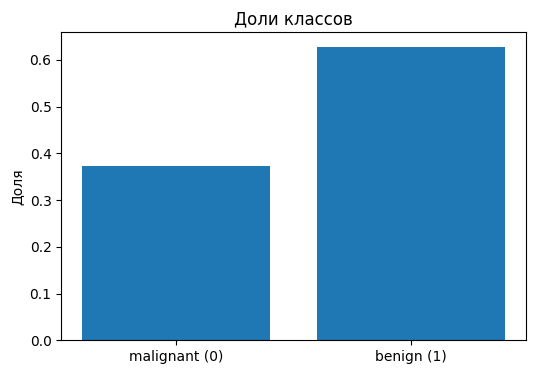

In [7]:
print("Пропуски по признакам:")
display(X.isna().sum().sort_values(ascending=False).head())

print("\nБазовая статистика:")
display(X.describe().T.head(10))

class_share = y.value_counts(normalize=True).sort_index()
plt.figure(figsize=(6, 4))
plt.bar(["malignant (0)", "benign (1)"], class_share.values)
plt.title("Доли классов")
plt.ylabel("Доля")
plt.show()

## Шаг 1. Разделение данных и стандартизация

Ниже нужно:
1. разбить выборку на train и test;
2. стандартизовать признаки только по train-части;
3. получить `X_train_scaled` и `X_test_scaled`.

Подсказка:
- используйте `train_test_split(..., test_size=0.2, random_state=42, stratify=y)`;
- `StandardScaler().fit(...)` делаем **только на train**.

In [9]:
# YOUR CODE HERE
# 1) Разбейте данные на train/test
# 2) Создайте scaler
# 3) Обучите scaler на train
# 4) Преобразуйте X_train и X_test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (455, 30)
Test shape: (114, 30)


## Шаг 2. Реализуем сигмоиду

Допишите функцию `sigmoid(z)`.

Проверка:
- `sigmoid(0)` должно быть равно `0.5`;
- функция должна работать и со скалярами, и с `numpy`-массивами.

In [11]:
def sigmoid(z):
    # YOUR CODE HERE
    return 1 / (1 + np.exp(-z))
    

print("sigmoid(0) =", sigmoid(0))
print("sigmoid([-1, 0, 1]) =", sigmoid(np.array([-1.0, 0.0, 1.0])))

sigmoid(0) = 0.5
sigmoid([-1, 0, 1]) = [0.26894142 0.5        0.73105858]


## Шаг 3. Реализуем log-loss

Напишите функцию `compute_log_loss(y_true, y_pred_proba)`.

Важно:
- чтобы избежать `log(0)`, используйте `np.clip(y_pred_proba, 1e-15, 1 - 1e-15)`.

In [13]:
def compute_log_loss(y_true, y_pred_proba):
    # YOUR CODE HERE
    y_pred_proba = np.clip(y_pred_proba, 1e-15, 1 - 1e-15)
    N = len(y_true)
    loss = - (y_true @ np.log(y_pred_proba) + (1 - y_true) @ np.log(1 - y_pred_proba)) / N
    return loss

toy_y = np.array([0, 1, 1, 0])
toy_p = np.array([0.1, 0.9, 0.8, 0.3])
print("Toy log-loss:", compute_log_loss(toy_y, toy_p))

Toy log-loss: 0.19763488164214868


## Шаг 4. Один шаг градиентного спуска

Напомним:
- $z = Xw + b$
- $\hat{p} = \sigma(z)$

Градиенты для log-loss:
$$
dw = \frac{1}{n} X^T(\hat{p} - y), \qquad db = \frac{1}{n}\sum(\hat{p} - y)
$$

Ниже нужно реализовать функцию, которая считает:
- вероятности,
- loss,
- градиенты $dw$, $db$.

In [17]:
def forward_backward(X, y, w, b):
    # YOUR CODE HERE
    # 1) посчитать z
    # 2) посчитать p = sigmoid(z)
    # 3) посчитать loss
    # 4) посчитать dw и db
    ...
    N = len(y)
    z = X @ w + b
    p = sigmoid(z)
    loss = compute_log_loss(y, p)
    p = np.clip(p, 1e-15, 1 - 1e-15)
    loss_derivation = (-1 / N) * (y / p - (1 -y) / (1 - p))
    sigmoid_derivatation = (np.exp(-z) / (1 + np.exp(-z)) ** 2) #однако это равно p(1 - p)
    dw = X.T @ (loss_derivation *  sigmoid_derivatation) # Однако второй множетель и правда равен (p-y) * (1 / N)
    db = np.array([1 for i in range(N)]) @ (loss_derivation *  sigmoid_derivatation)  
    return p, loss, dw, db

n_features = X_train_scaled.shape[1]
w0 = np.zeros(n_features)
b0 = 0.0

p0, loss0, dw0, db0 = forward_backward(X_train_scaled, y_train.values, w0, b0)
print("Initial loss:", loss0)
print("dw shape:", dw0.shape)
print("db:", db0)

Initial loss: 0.6931471805599453
dw shape: (30,)
db: -0.12637362637362637


## Шаг 5. Собираем модель в класс

Допишите методы:
- `fit`
- `predict_proba`
- `predict`

Требования:
- обучение через градиентный спуск;
- сохранять историю значения loss;
- в `predict` использовать порог `threshold`.

In [29]:
from sklearn.metrics import accuracy_score, f1_score

class MyLogisticRegressionGD:
    def __init__(self, learning_rate=0.05, n_iters=3000, threshold=0.5, reg = 0):
        self.learning_rate = learning_rate
        self.reg = reg
        self.n_iters = n_iters
        self.threshold = threshold
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        # YOUR CODE HERE
        # 1) инициализируйте w и b
        # 2) в цикле вызовите forward_backward
        # 3) обновите параметры
        # 4) сохраните loss в self.loss_history
        print('--Градиентный спуск начался--')
        print(f'Параметры: learning_rate = {self.learning_rate}, regularization = {self.reg}')
        N = X.shape[0]
        D = X.shape[1]
        self.w = np.array([0.0] * D)
        self.b = 0.0
        for iter in range(self.n_iters):
            p, loss, dw, db = forward_backward(X, y, self.w, self.b)
            self.loss_history.append(loss)
            w_diff = self.learning_rate * (dw + 2 * self.reg * self.w)
            self.w -= w_diff 
            # В отличие от w, bias не требует регуляризации
            self.b = self.b - self.learning_rate * db
            #Если евклидовая норма вектора изменения весов достаточно маленькая
            #Евклидовая норма это сумма квадратов координат
            if (np.linalg.norm(dw) < 1e-4):
                print(f'--Градиентный пуск закончен на итерации {iter}--')
                y_preds = self.predict(X)
                print(f'Accuracy train = {accuracy_score(y, y_preds)}')
                print(f'F1 train = {f1_score(y, y_preds)}')
                return self
            if iter % 1000 == 0:
                print(f'Итерация {iter}: норма градиента = {np.linalg.norm(dw)}')
        print('--Градиентный спуск сошелся не до конца--')
        y_preds = self.predict(X)
        print(f'Accuracy train = {accuracy_score(y, y_preds)}')
        print(f'F1 train = {f1_score(y, y_preds)}')
        return self

    def predict_proba(self, X):
        # YOUR CODE HERE
        proba = sigmoid(X @ self.w + self.b)
        return np.column_stack((1 - proba, proba))

    def predict(self, X):
        # YOUR CODE HERE
        proba_1 = self.predict_proba(X)[:, 1]
        preds = (proba_1 >= self.threshold).astype(int)
        return preds

## Шаг 6. Обучаем свою модель

Попробуйте обучить свою модель и посмотрите:
- уменьшается ли `loss`;
- какое качество получается на test.

### Эксперимент с learning rate

Из экспериментов ниже можно выявить следующее:
- требование чтобы выходить из цикла у меня было сильно жесткое. Не так быстро начинают падать градиенты. Часть этого кода становится рудиментом как будто
- чем меньше learning rate тем плавнее и медленнее падает loss. Такая же штука с градиентом весов
- c ростом learning rate можно заметить рост метрик на train, быстрый спад loss и градиентов. Но переобучение растет, как можно видеть.
- самым оптимальным является learning_rate = 0.05. Тут и траин метрики нормальные, и тестовые метрики не так сильно отстают от трейновских.


#### Эксперимент 1: learning_rate = 5e-3

--Градиентный спуск начался--
Параметры: learning_rate = 0.005, regularization = 0
Итерация 0: норма градиента = 1.4249821099967486
Итерация 1000: норма градиента = 0.09536782094007008
Итерация 2000: норма градиента = 0.05590520490928855
Итерация 3000: норма градиента = 0.04094357335026355
Итерация 4000: норма градиента = 0.03282213887664169
Итерация 5000: норма градиента = 0.027655346584774147
Итерация 6000: норма градиента = 0.024055054121342588
Итерация 7000: норма градиента = 0.021391207119220077
Итерация 8000: норма градиента = 0.019333707278471397
Итерация 9000: норма градиента = 0.01769211190265825
Итерация 10000: норма градиента = 0.01634860021837211
Итерация 11000: норма градиента = 0.015226284035237575
Итерация 12000: норма градиента = 0.014272816696975495
Итерация 13000: норма градиента = 0.013451307221380595
Итерация 14000: норма градиента = 0.012734997849021204
Итерация 15000: норма градиента = 0.012104001671519394
Итерация 16000: норма градиента = 0.011543225565113259
Ите

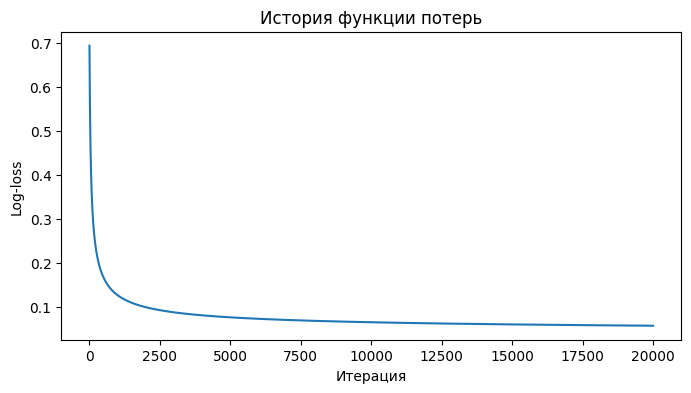

In [31]:
from sklearn.metrics import accuracy_score, f1_score

my_model = MyLogisticRegressionGD(
    learning_rate= 0.005,   # Достаточно маленький learning_rate
    n_iters=20000,         
    threshold=0.5
)

# YOUR CODE HERE
# обучите модель
my_model.fit(X_train_scaled, y_train)

y_preds = my_model.predict(X_test_scaled)
print(f"Accuracy test = {accuracy_score(y_test, y_preds)}")
print(f"F1 test = {f1_score(y_test, y_preds)}")


plt.figure(figsize=(8, 4))
plt.plot(my_model.loss_history)
plt.title("История функции потерь")
plt.xlabel("Итерация")
plt.ylabel("Log-loss")
plt.show()

М

#### Эксперимент 2: learning_rate = 1e-4

--Градиентный спуск начался--
Параметры: learning_rate = 0.0001, regularization = 0
Итерация 0: норма градиента = 1.4249821099967486
Итерация 1000: норма градиента = 1.0502998558454624
Итерация 2000: норма градиента = 0.821022614349909
Итерация 3000: норма градиента = 0.6748274974047629
Итерация 4000: норма градиента = 0.5746454943201276
Итерация 5000: норма градиента = 0.5019227786780814
Итерация 6000: норма градиента = 0.4467757470053326
Итерация 7000: норма градиента = 0.4035198474357062
Итерация 8000: норма градиента = 0.36866784562010474
Итерация 9000: норма градиента = 0.3399664801290319
Итерация 10000: норма градиента = 0.3158973376199106
Итерация 11000: норма градиента = 0.29540126462452615
Итерация 12000: норма градиента = 0.2777178689230744
Итерация 13000: норма градиента = 0.2622877650360124
Итерация 14000: норма градиента = 0.24869072987354282
Итерация 15000: норма градиента = 0.2366052821786043
Итерация 16000: норма градиента = 0.225781509417941
Итерация 17000: норма гради

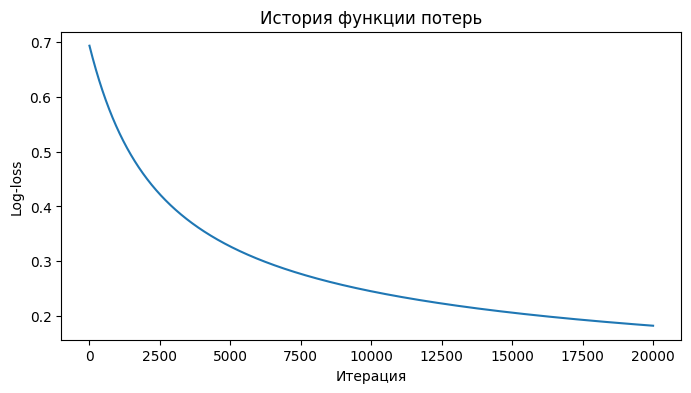

In [33]:
from sklearn.metrics import accuracy_score, f1_score

my_model = MyLogisticRegressionGD(
    learning_rate= 0.0001,   
    n_iters=20000,         
    threshold=0.5
)

# YOUR CODE HERE
# обучите модель
my_model.fit(X_train_scaled, y_train)

y_preds = my_model.predict(X_test_scaled)
print(f"Accuracy test = {accuracy_score(y_test, y_preds)}")
print(f"F1 test = {f1_score(y_test, y_preds)}")

plt.figure(figsize=(8, 4))
plt.plot(my_model.loss_history)
plt.title("История функции потерь")
plt.xlabel("Итерация")
plt.ylabel("Log-loss")
plt.show()

#### Эксперимент 3: learning_rate = 0.01

--Градиентный спуск начался--
Параметры: learning_rate = 0.01, regularization = 0
Итерация 0: норма градиента = 1.4249821099967486
Итерация 1000: норма градиента = 0.05587438820179145
Итерация 2000: норма градиента = 0.032811641777996475
Итерация 3000: норма градиента = 0.024049568314485514
Итерация 4000: норма градиента = 0.019330307259048444
Итерация 5000: норма градиента = 0.01634628105023835
Итерация 6000: норма градиента = 0.014271131857356028
Итерация 7000: норма градиента = 0.012733717308100528
Итерация 8000: норма градиента = 0.011542218590709566
Итерация 9000: норма градиента = 0.01058736325028893
Итерация 10000: норма градиента = 0.009802250788032508
Итерация 11000: норма градиента = 0.009143564792049471
Итерация 12000: норма градиента = 0.00858196299563173
Итерация 13000: норма градиента = 0.008096806746577454
Итерация 14000: норма градиента = 0.007673105710675965
Итерация 15000: норма градиента = 0.007299665632698544
Итерация 16000: норма градиента = 0.006967923138542079
Ит

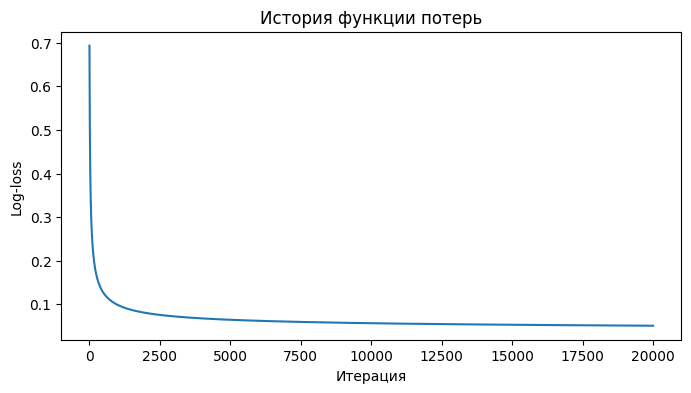

In [34]:
from sklearn.metrics import accuracy_score, f1_score

my_model = MyLogisticRegressionGD(
    learning_rate= 0.01,   
    n_iters=20000,         
    threshold=0.5
)

# YOUR CODE HERE
# обучите модель
my_model.fit(X_train_scaled, y_train)

y_preds = my_model.predict(X_test_scaled)
print(f"Accuracy test = {accuracy_score(y_test, y_preds)}")
print(f"F1 test = {f1_score(y_test, y_preds)}")

plt.figure(figsize=(8, 4))
plt.plot(my_model.loss_history)
plt.title("История функции потерь")
plt.xlabel("Итерация")
plt.ylabel("Log-loss")
plt.show()

#### Эксперимент 4: learning_rate = 0.05

--Градиентный спуск начался--
Параметры: learning_rate = 0.05, regularization = 0
Итерация 0: норма градиента = 1.4249821099967486
Итерация 1000: норма градиента = 0.01632757306322726
Итерация 2000: норма градиента = 0.009796846886723557
Итерация 3000: норма градиента = 0.007297135686111181
Итерация 4000: норма градиента = 0.005941289077735592
Итерация 5000: норма градиента = 0.00508436763244428
Итерация 6000: норма градиента = 0.0044874675060701625
Итерация 7000: норма градиента = 0.004042690598636242
Итерация 8000: норма градиента = 0.003696695002895395
Итерация 9000: норма градиента = 0.0034205283437768854
Итерация 10000: норма градиента = 0.0031961450542438924
Итерация 11000: норма градиента = 0.003010869945177219
Итерация 12000: норма градиента = 0.0028553850512132452
Итерация 13000: норма градиента = 0.00272284538378081
Итерация 14000: норма градиента = 0.0026082581592472972
Итерация 15000: норма градиента = 0.0025079731821558947
Итерация 16000: норма градиента = 0.00241928981877

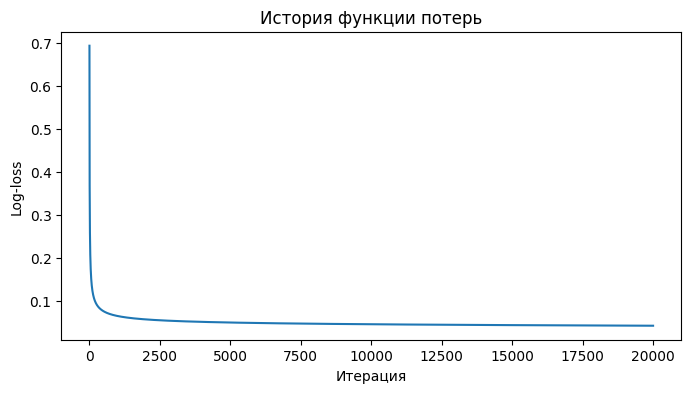

In [35]:
from sklearn.metrics import accuracy_score, f1_score

my_model = MyLogisticRegressionGD(
    learning_rate= 0.05,   
    n_iters=20000,         
    threshold=0.5
)

# YOUR CODE HERE
# обучите модель
my_model.fit(X_train_scaled, y_train)

y_preds = my_model.predict(X_test_scaled)
print(f"Accuracy test = {accuracy_score(y_test, y_preds)}")
print(f"F1 test = {f1_score(y_test, y_preds)}")

plt.figure(figsize=(8, 4))
plt.plot(my_model.loss_history)
plt.title("История функции потерь")
plt.xlabel("Итерация")
plt.ylabel("Log-loss")
plt.show()

#### Эксперимент 5: learning_rate = 0.1

--Градиентный спуск начался--
Параметры: learning_rate = 0.1, regularization = 0
Итерация 0: норма градиента = 1.4249821099967486
Итерация 1000: норма градиента = 0.009789979177057866
Итерация 2000: норма градиента = 0.0059394722660610225
Итерация 3000: норма градиента = 0.00448668694388946
Итерация 4000: норма градиента = 0.003696243192422909
Итерация 5000: норма градиента = 0.003195832351672883
Итерация 6000: норма градиента = 0.0028551548380283892
Итерация 7000: норма градиента = 0.0026080826007906293
Итерация 8000: норма градиента = 0.002419151502921649
Итерация 9000: норма градиента = 0.0022689566094859456
Итерация 10000: норма градиента = 0.0021461588861430275
Итерация 11000: норма градиента = 0.0020436335854345164
Итерация 12000: норма градиента = 0.001956621177158698
Итерация 13000: норма градиента = 0.0018817858052706047
Итерация 14000: норма градиента = 0.001816701388819537
--Градиентный спуск сошелся не до конца--
Accuracy train = 0.9912087912087912
F1 train = 0.993006993006

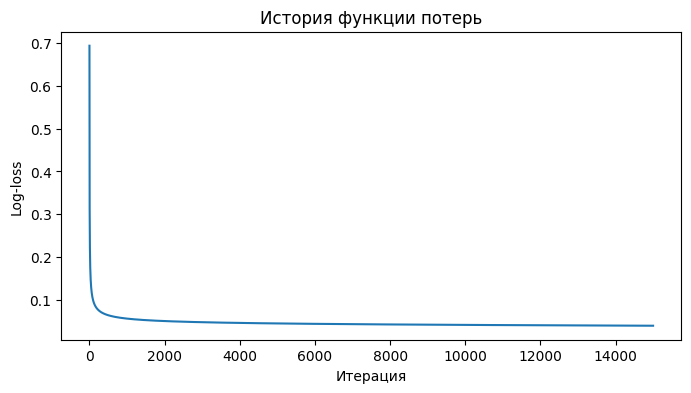

In [9]:
from sklearn.metrics import accuracy_score, f1_score

my_model = MyLogisticRegressionGD(
    learning_rate= 0.1,   
    n_iters=15000,         
    threshold=0.5
)

# YOUR CODE HERE
# обучите модель
my_model.fit(X_train_scaled, y_train)

y_preds = my_model.predict(X_test_scaled)
print(f"Accuracy test = {accuracy_score(y_test, y_preds)}")
print(f"F1 test = {f1_score(y_test, y_preds)}")

plt.figure(figsize=(8, 4))
plt.plot(my_model.loss_history)
plt.title("История функции потерь")
plt.xlabel("Итерация")
plt.ylabel("Log-loss")
plt.show()

In [11]:
import pandas as pd
print(pd.Series(my_model.w).abs().sort_values(ascending=False)[:11])

21    2.410573
10    2.255902
5     2.127430
13    1.940176
28    1.783025
23    1.759258
27    1.628267
20    1.606948
26    1.597140
24    1.339445
7     1.131017
dtype: float64


#### Эксперимент 6: learning_rate = 1

--Градиентный спуск начался--
Параметры: learning_rate = 1, regularization = 0
Итерация 0: норма градиента = 1.4249821099967486
Итерация 1000: норма градиента = 0.0021434537670181318
Итерация 2000: норма градиента = 0.0015526384667295845
Итерация 3000: норма градиента = 0.0013325163689964581
Итерация 4000: норма градиента = 0.001208951020559973
Итерация 5000: норма градиента = 0.001122249374920165
Итерация 6000: норма градиента = 0.0010525085746450446
Итерация 7000: норма градиента = 0.0009919200212750623
Итерация 8000: норма градиента = 0.000937370429217662
Итерация 9000: норма градиента = 0.000887651799329806
Итерация 10000: норма градиента = 0.0008422407740361398
Итерация 11000: норма градиента = 0.0008008043095416965
Итерация 12000: норма градиента = 0.0007630379488206702
Итерация 13000: норма градиента = 0.0007286318255651469
Итерация 14000: норма градиента = 0.00069727512465516
Итерация 15000: норма градиента = 0.0006686671086986294
Итерация 16000: норма градиента = 0.00064252567

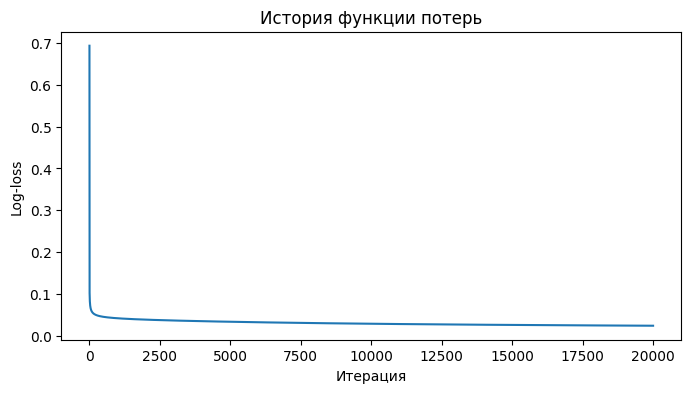

In [39]:
from sklearn.metrics import accuracy_score, f1_score

my_model = MyLogisticRegressionGD(
    learning_rate= 1,   
    n_iters=20000,         
    threshold=0.5
)

# YOUR CODE HERE
# обучите модель
my_model.fit(X_train_scaled, y_train)

y_preds = my_model.predict(X_test_scaled)
print(f"Accuracy test = {accuracy_score(y_test, y_preds)}")
print(f"F1 test = {f1_score(y_test, y_preds)}")

plt.figure(figsize=(8, 4))
plt.plot(my_model.loss_history)
plt.title("История функции потерь")
plt.xlabel("Итерация")
plt.ylabel("Log-loss")
plt.show()

In [4]:
import pandas as pd
print(pd.Series(my_model.w).abs().sort_values(ascending=False)[:11])

5     10.414828
26     6.966144
16     6.580824
13     6.271585
23     6.090584
10     5.431881
17     5.140821
6      3.721625
9      3.588747
21     3.362473
20     3.032275
dtype: float64


### Эксперимент с количеством итераций

Проведем эксперимент с лучшей моделью learning_rate=0.05 и уменьшим количество итераций до 10000

Можно видеть следующую картину: Метрики на трейн просели. Причем это не из-за уменьшенного переобучения, оно осталось на том же уровне.

In [12]:
from sklearn.metrics import accuracy_score, f1_score

my_model = MyLogisticRegressionGD(
    learning_rate= 0.05,   
    n_iters=10000,         
    threshold=0.5
)

# YOUR CODE HERE
# обучите модель
my_model.fit(X_train_scaled, y_train)

y_preds = my_model.predict(X_test_scaled)
print(f"Accuracy test = {accuracy_score(y_test, y_preds)}")
print(f"F1 test = {f1_score(y_test, y_preds)}")


--Градиентный спуск начался--
Параметры: learning_rate = 0.05, regularization = 0
Итерация 0: норма градиента = 1.4249821099967486
Итерация 1000: норма градиента = 0.01632757306322726
Итерация 2000: норма градиента = 0.009796846886723557
Итерация 3000: норма градиента = 0.007297135686111181
Итерация 4000: норма градиента = 0.005941289077735592
Итерация 5000: норма градиента = 0.00508436763244428
Итерация 6000: норма градиента = 0.0044874675060701625
Итерация 7000: норма градиента = 0.004042690598636242
Итерация 8000: норма градиента = 0.003696695002895395
Итерация 9000: норма градиента = 0.0034205283437768854
--Градиентный спуск сошелся не до конца--
Accuracy train = 0.989010989010989
F1 train = 0.9912739965095986
Accuracy test = 0.9736842105263158
F1 test = 0.979020979020979


Можно видеть, что повыся количество итераций до 30000, мы не смогли улучшить метрики. Градиенты стали слишком медленно падать. Так что нету смысла иметь огромное количество итераций, если они не приносят вклад в метрику.

In [14]:
from sklearn.metrics import accuracy_score, f1_score

my_model = MyLogisticRegressionGD(
    learning_rate= 0.05,   
    n_iters=30000,         
    threshold=0.5
)

# YOUR CODE HERE
# обучите модель
my_model.fit(X_train_scaled, y_train)

y_preds = my_model.predict(X_test_scaled)
print(f"Accuracy test = {accuracy_score(y_test, y_preds)}")
print(f"F1 test = {f1_score(y_test, y_preds)}")


--Градиентный спуск начался--
Параметры: learning_rate = 0.05, regularization = 0
Итерация 0: норма градиента = 1.4249821099967486
Итерация 1000: норма градиента = 0.01632757306322726
Итерация 2000: норма градиента = 0.009796846886723557
Итерация 3000: норма градиента = 0.007297135686111181
Итерация 4000: норма градиента = 0.005941289077735592
Итерация 5000: норма градиента = 0.00508436763244428
Итерация 6000: норма градиента = 0.0044874675060701625
Итерация 7000: норма градиента = 0.004042690598636242
Итерация 8000: норма градиента = 0.003696695002895395
Итерация 9000: норма градиента = 0.0034205283437768854
Итерация 10000: норма градиента = 0.0031961450542438924
Итерация 11000: норма градиента = 0.003010869945177219
Итерация 12000: норма градиента = 0.0028553850512132452
Итерация 13000: норма градиента = 0.00272284538378081
Итерация 14000: норма градиента = 0.0026082581592472972
Итерация 15000: норма градиента = 0.0025079731821558947
Итерация 16000: норма градиента = 0.00241928981877

### Эксперименты с регуляризацией

Проводила эксперименты на лучшем learning_rate = 0.05 и learning_rate = 1 (с лучшей траин метрикой и большим переобучением). Из этих экспериментов ниже сделала следующие выводы:
- Регуляризация не нужна вовсе, а иногда даже вредит для нашей лучшей модели. Переобучение падает, но и вместе с тем и метрики.
 - Для переобученной модели регуляризация смогла вывести модель на уровень нашей лучшей модели (по тестовым метрикам конечно). Она менее переобученная, но на трейне метрики упали слегка. Хотя уровень падения не слишком критичен.Лучший коэффициент регуляризации = 1e-3

Regularization = 1e-05
--Градиентный спуск начался--
Параметры: learning_rate = 0.05, regularization = 1e-05
Итерация 0: норма градиента = 1.4249821099967486
Итерация 1000: норма градиента = 0.0163461271147276
Итерация 2000: норма градиента = 0.009818779414112612
Итерация 3000: норма градиента = 0.007321184366319285
Итерация 4000: норма градиента = 0.005966654958443744
Итерация 5000: норма градиента = 0.00511043387902151
Итерация 6000: норма градиента = 0.004513967659779497
--Градиентный спуск сошелся не до конца--
Accuracy train = 0.989010989010989
F1 train = 0.9912739965095986
Accuracy test = 0.9736842105263158
F1 test = 0.979020979020979


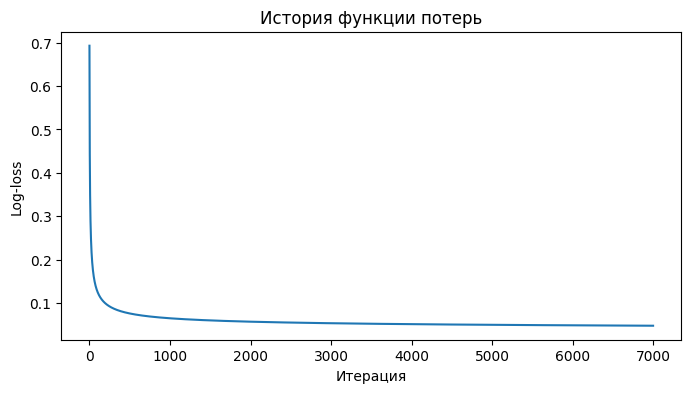

Regularization = 0.0001
--Градиентный спуск начался--
Параметры: learning_rate = 0.05, regularization = 0.0001
Итерация 0: норма градиента = 1.4249821099967486
Итерация 1000: норма градиента = 0.016513912122926043
Итерация 2000: норма градиента = 0.010018733700215388
Итерация 3000: норма градиента = 0.007542399891014727
Итерация 4000: норма градиента = 0.006202481067349259
Итерация 5000: норма градиента = 0.005356020273748499
Итерация 6000: норма градиента = 0.004767484643356576
--Градиентный спуск сошелся не до конца--
Accuracy train = 0.989010989010989
F1 train = 0.9912739965095986
Accuracy test = 0.9736842105263158
F1 test = 0.979020979020979


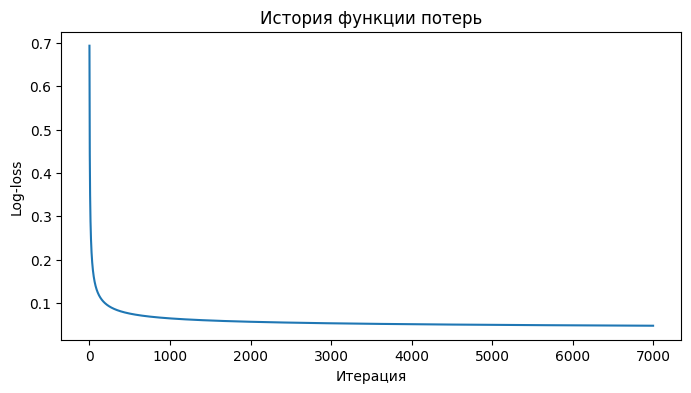

Regularization = 0.001
--Градиентный спуск начался--
Параметры: learning_rate = 0.05, regularization = 0.001
Итерация 0: норма градиента = 1.4249821099967486
Итерация 1000: норма градиента = 0.01826449153846957
Итерация 2000: норма градиента = 0.012230944731335822
Итерация 3000: норма градиента = 0.01011861967712302
Итерация 4000: норма градиента = 0.009085593179408782
Итерация 5000: норма градиента = 0.008504512066144682
Итерация 6000: норма градиента = 0.008150998647739919
--Градиентный спуск сошелся не до конца--
Accuracy train = 0.989010989010989
F1 train = 0.9912739965095986
Accuracy test = 0.9824561403508771
F1 test = 0.9861111111111112


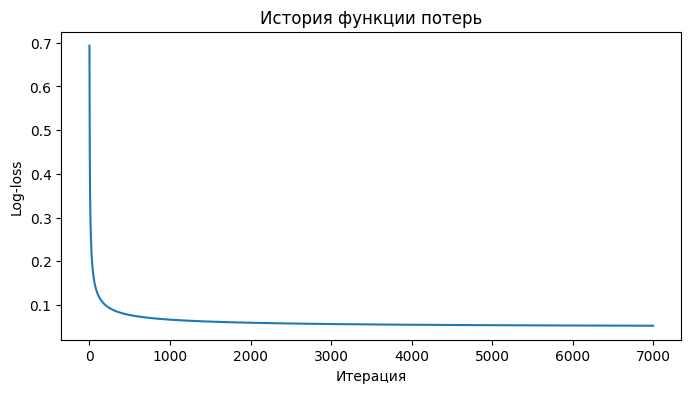

Regularization = 0.01
--Градиентный спуск начался--
Параметры: learning_rate = 0.05, regularization = 0.01
Итерация 0: норма градиента = 1.4249821099967486
Итерация 1000: норма градиента = 0.03878747108754682
Итерация 2000: норма градиента = 0.03766515864431751
Итерация 3000: норма градиента = 0.03759162082542756
Итерация 4000: норма градиента = 0.03758080021849129
Итерация 5000: норма градиента = 0.03757865173177993
Итерация 6000: норма градиента = 0.03757818701462572
--Градиентный спуск сошелся не до конца--
Accuracy train = 0.9868131868131869
F1 train = 0.9895470383275261
Accuracy test = 0.9736842105263158
F1 test = 0.9793103448275863


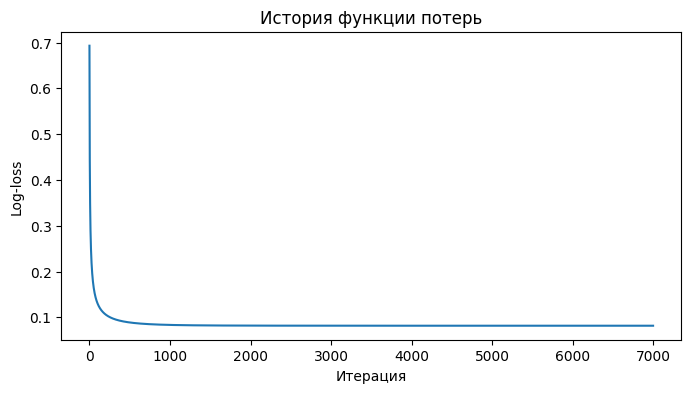

Regularization = 0.1
--Градиентный спуск начался--
Параметры: learning_rate = 0.05, regularization = 0.1
Итерация 0: норма градиента = 1.4249821099967486
Итерация 1000: норма градиента = 0.17254930129639837
Итерация 2000: норма градиента = 0.17253913929479592
Итерация 3000: норма градиента = 0.17253901686056258
Итерация 4000: норма градиента = 0.17253901536134927
Итерация 5000: норма градиента = 0.1725390153429877
Итерация 6000: норма градиента = 0.17253901534276278
--Градиентный спуск сошелся не до конца--
Accuracy train = 0.9582417582417583
F1 train = 0.967741935483871
Accuracy test = 0.9473684210526315
F1 test = 0.9594594594594595


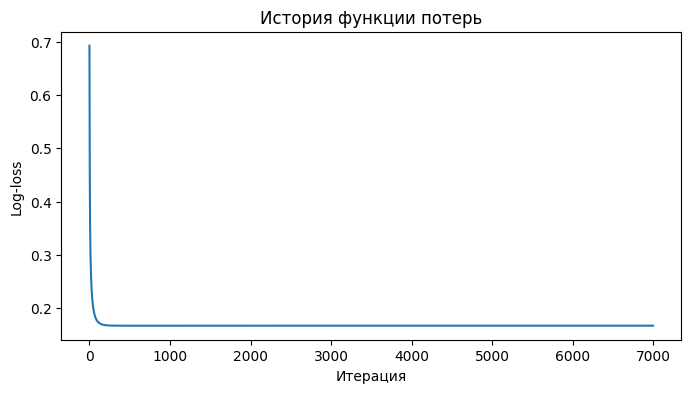

In [20]:
from sklearn.metrics import accuracy_score, f1_score

for reg in np.logspace(-5, -1, 5):
    my_model = MyLogisticRegressionGD(
        learning_rate= 0.05,   
        n_iters=7000,         
        threshold=0.5, 
        reg=reg
    )
    print(f'Regularization = {reg}')
    
    my_model.fit(X_train_scaled, y_train)

    y_preds = my_model.predict(X_test_scaled)
    print(f"Accuracy test = {accuracy_score(y_test, y_preds)}")
    print(f"F1 test = {f1_score(y_test, y_preds)}")

    plt.figure(figsize=(8, 4))
    plt.plot(my_model.loss_history)
    plt.title("История функции потерь")
    plt.xlabel("Итерация")
    plt.ylabel("Log-loss")
    plt.show()



Regularization = 1e-05
--Градиентный спуск начался--
Параметры: learning_rate = 1, regularization = 1e-05
Итерация 0: норма градиента = 1.4249821099967486
Итерация 1000: норма градиента = 0.002175743119828001
Итерация 2000: норма градиента = 0.0015868699565900557
Итерация 3000: норма градиента = 0.0013673979013670997
Итерация 4000: норма градиента = 0.0012455178663455218
Итерация 5000: норма градиента = 0.0011619568689313737
Итерация 6000: норма градиента = 0.0010967984880865176
Итерация 7000: норма градиента = 0.0010419631161416548
Итерация 8000: норма градиента = 0.0009939030017239365
Итерация 9000: норма градиента = 0.0009509826645781683
--Градиентный спуск сошелся не до конца--
Accuracy train = 0.989010989010989
F1 train = 0.9912126537785588
Accuracy test = 0.9649122807017544
F1 test = 0.9722222222222222


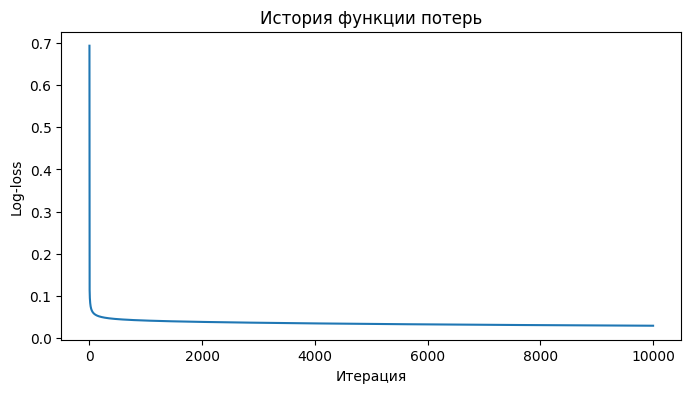

Regularization = 0.0001
--Градиентный спуск начался--
Параметры: learning_rate = 1, regularization = 0.0001
Итерация 0: норма градиента = 1.4249821099967486
Итерация 1000: норма градиента = 0.0025302221655207615
Итерация 2000: норма градиента = 0.0020223025481913457
Итерация 3000: норма градиента = 0.0018595491267627338
Итерация 4000: норма градиента = 0.0017856961062310567
Итерация 5000: норма градиента = 0.0017457479930544162
Итерация 6000: норма градиента = 0.0017216118290525543
Итерация 7000: норма градиента = 0.0017059354708147724
Итерация 8000: норма градиента = 0.001695255246186855
Итерация 9000: норма градиента = 0.0016877413549230798
--Градиентный спуск сошелся не до конца--
Accuracy train = 0.9912087912087912
F1 train = 0.993006993006993
Accuracy test = 0.9649122807017544
F1 test = 0.9722222222222222


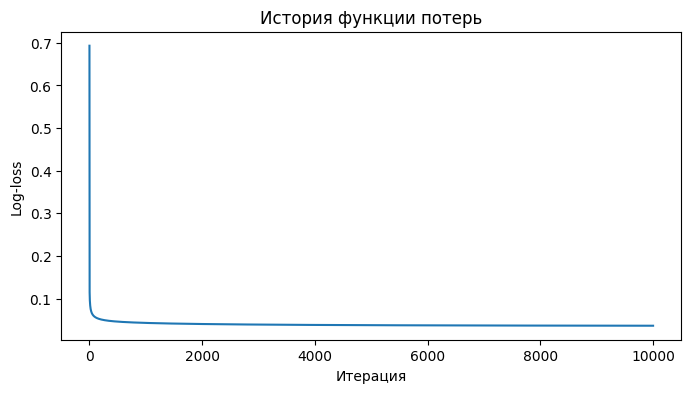

Regularization = 0.001
--Градиентный спуск начался--
Параметры: learning_rate = 1, regularization = 0.001
Итерация 0: норма градиента = 1.4249821099967486
Итерация 1000: норма градиента = 0.0073914033492622775
Итерация 2000: норма градиента = 0.007372662004283845
Итерация 3000: норма градиента = 0.007371954895939675
Итерация 4000: норма градиента = 0.00737190295746584
Итерация 5000: норма градиента = 0.007371898435209538
Итерация 6000: норма градиента = 0.007371898008030607
Итерация 7000: норма градиента = 0.007371897965260629
Итерация 8000: норма градиента = 0.007371897960785937
Итерация 9000: норма градиента = 0.007371897960302294
--Градиентный спуск сошелся не до конца--
Accuracy train = 0.989010989010989
F1 train = 0.9912739965095986
Accuracy test = 0.9824561403508771
F1 test = 0.9861111111111112


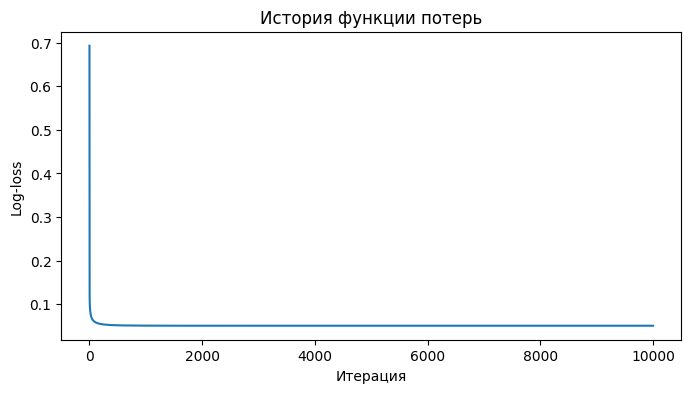

Regularization = 0.01
--Градиентный спуск начался--
Параметры: learning_rate = 1, regularization = 0.01
Итерация 0: норма градиента = 1.4249821099967486
Итерация 1000: норма градиента = 0.037578045980727684
Итерация 2000: норма градиента = 0.037578045980697326
Итерация 3000: норма градиента = 0.037578045980697326
Итерация 4000: норма градиента = 0.037578045980697326
Итерация 5000: норма градиента = 0.037578045980697326
Итерация 6000: норма градиента = 0.037578045980697326
Итерация 7000: норма градиента = 0.037578045980697326
Итерация 8000: норма градиента = 0.037578045980697326
Итерация 9000: норма градиента = 0.037578045980697326
--Градиентный спуск сошелся не до конца--
Accuracy train = 0.9868131868131869
F1 train = 0.9895470383275261
Accuracy test = 0.9736842105263158
F1 test = 0.9793103448275863


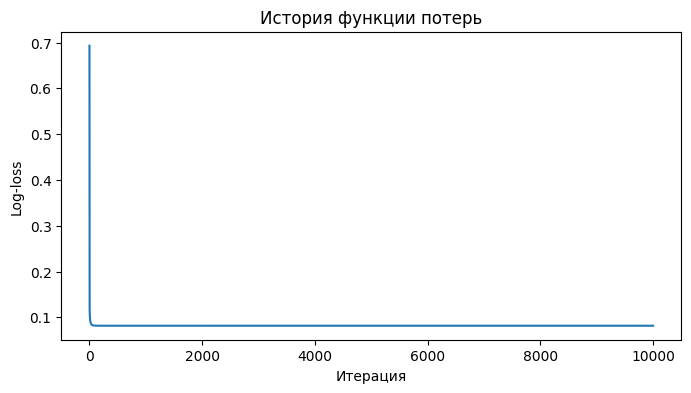

Regularization = 0.1
--Градиентный спуск начался--
Параметры: learning_rate = 1, regularization = 0.1
Итерация 0: норма градиента = 1.4249821099967486
Итерация 1000: норма градиента = 0.17253901534276003
Итерация 2000: норма градиента = 0.17253901534276003
Итерация 3000: норма градиента = 0.17253901534276003
Итерация 4000: норма градиента = 0.17253901534276003
Итерация 5000: норма градиента = 0.17253901534276003
Итерация 6000: норма градиента = 0.17253901534276003
Итерация 7000: норма градиента = 0.17253901534276003
Итерация 8000: норма градиента = 0.17253901534276003
Итерация 9000: норма градиента = 0.17253901534276003
--Градиентный спуск сошелся не до конца--
Accuracy train = 0.9582417582417583
F1 train = 0.967741935483871
Accuracy test = 0.9473684210526315
F1 test = 0.9594594594594595


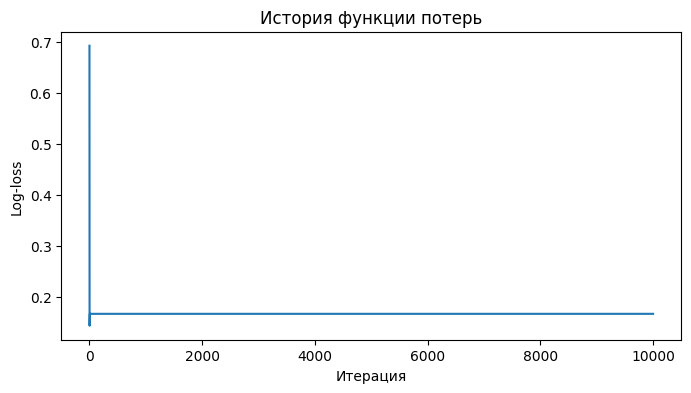

In [18]:
from sklearn.metrics import accuracy_score, f1_score

for reg in np.logspace(-5, -1, 5):
    my_model = MyLogisticRegressionGD(
        learning_rate= 1,   
        n_iters=10000,         
        threshold=0.5, 
        reg=reg
    )
    print(f'Regularization = {reg}')
    
    my_model.fit(X_train_scaled, y_train)

    y_preds = my_model.predict(X_test_scaled)
    print(f"Accuracy test = {accuracy_score(y_test, y_preds)}")
    print(f"F1 test = {f1_score(y_test, y_preds)}")

    plt.figure(figsize=(8, 4))
    plt.plot(my_model.loss_history)
    plt.title("История функции потерь")
    plt.xlabel("Итерация")
    plt.ylabel("Log-loss")
    plt.show()



## Шаг 7. Оценка качества своей модели

Заполните код ниже и посчитайте:
- accuracy,
- precision,
- recall,
- f1,
- ROC-AUC.

Подсказка:
- для ROC-AUC нужны **вероятности**, а не классы.

В коде ниже я использую свою модель learning_rate = 0.05 для сравнения. 

In [16]:
# YOUR CODE HERE
my_model = MyLogisticRegressionGD(
    learning_rate= 0.05,   
    n_iters=20000,         
    threshold=0.5, 
).fit(X_train_scaled, y_train)
my_proba_test = my_model.predict_proba(X_test_scaled)[:, 1]
my_pred_test = my_model.predict(X_test_scaled)

my_metrics = {
    "accuracy": accuracy_score(y_test, my_pred_test),
    "precision": precision_score(y_test, my_pred_test),
    "recall": recall_score(y_test, my_pred_test),
    "f1": f1_score(y_test, my_pred_test),
    "roc_auc": roc_auc_score(y_test, my_proba_test),
}

pd.Series(my_metrics).round(4)

--Градиентный спуск начался--
Параметры: learning_rate = 0.05, regularization = 0
Итерация 0: норма градиента = 1.4249821099967486
Итерация 1000: норма градиента = 0.01632757306322726
Итерация 2000: норма градиента = 0.009796846886723557
Итерация 3000: норма градиента = 0.007297135686111181
Итерация 4000: норма градиента = 0.005941289077735592
Итерация 5000: норма градиента = 0.00508436763244428
Итерация 6000: норма градиента = 0.0044874675060701625
Итерация 7000: норма градиента = 0.004042690598636242
Итерация 8000: норма градиента = 0.003696695002895395
Итерация 9000: норма градиента = 0.0034205283437768854
Итерация 10000: норма градиента = 0.0031961450542438924
Итерация 11000: норма градиента = 0.003010869945177219
Итерация 12000: норма градиента = 0.0028553850512132452
Итерация 13000: норма градиента = 0.00272284538378081
Итерация 14000: норма градиента = 0.0026082581592472972
Итерация 15000: норма градиента = 0.0025079731821558947
Итерация 16000: норма градиента = 0.00241928981877

accuracy     0.9825
precision    0.9861
recall       0.9861
f1           0.9861
roc_auc      0.9954
dtype: float64

## Шаг 8. Confusion matrix и ROC-кривая

Можно видеть, что ROC-AUC достаточно неплохой (площадь фигуры уже ближе к квадрату). Значит точки, которые имеют отрицательный класс имеют в основном вероятности меньше, чем у точек положительного класса. По графику могу сказать, что есть какой-то положительный класс, который имеет вероятность меньше, чем у некоторых объектов отрицательного класса. То есть вероятность того, что я возьму объект класса 0 и класса 1 и у класса 0 предсказанная вероятность будет ниже достаточно не плохая. По Confusion matrix у нас лишь 2 объекта перепутанных. Достаточно неплохая картина. По опыту скажу, что этот датасет слишком хороший. Слишком хорошие результаты.

ROC-AUC кривая строится по следующему принципу: точки сортируются по убыванию их вероятности. И идем по порядку сортированного массива. Стартуем рисовать от точки (0, 0). Если мы видим класс 1, то рисуем черточку вверх, если 0 - вправо. По  кривой можно заметить, что есть лишь один здоровый человек с какой-то большой вероятностью среди больных людей. В остальном вероятности проставлены почти везде верно. Значит подбор порога должен помочь, учитывая то, что есть класс 1, который мы отнесли ошибочно к классу 0.

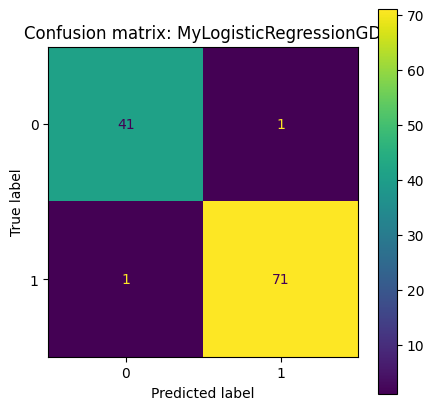

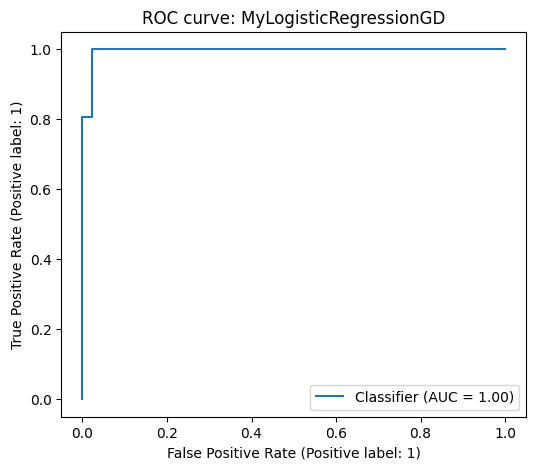

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [17]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, my_pred_test, ax=ax)
plt.title("Confusion matrix: MyLogisticRegressionGD")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, my_proba_test, ax=ax)
plt.title("ROC curve: MyLogisticRegressionGD")
plt.show()

print(classification_report(y_test, my_pred_test))

## Шаг 9. Сравнение с `scikit-learn`

Теперь обучите библиотечную модель и сравните её с вашей реализацией.

Рекомендации:
- используйте `LogisticRegression(max_iter=1000)`;
- обучайте на тех же стандартизованных данных.

In [18]:
sk_model = LogisticRegression(max_iter=1000)

# YOUR CODE HERE
# 1) обучите sk_model
# 2) получите вероятности и классы на test
# 3) посчитайте те же метрики
sk_model.fit(X_train_scaled, y_train)
sk_proba_test = sk_model.predict_proba(X_test_scaled)[:, 1]
sk_pred_test = sk_model.predict(X_test_scaled)
sk_metrics = {
    "accuracy": accuracy_score(y_test, sk_pred_test),
    "precision": precision_score(y_test, sk_pred_test),
    "recall": recall_score(y_test, sk_pred_test),
    "f1": f1_score(y_test, sk_pred_test),
    "roc_auc": roc_auc_score(y_test, sk_proba_test),
}

pd.Series(sk_metrics).round(4)

accuracy     0.9825
precision    0.9861
recall       0.9861
f1           0.9861
roc_auc      0.9954
dtype: float64

## Шаг 10. Сводная таблица сравнения

Сравните:
1. свою реализацию;
2. `scikit-learn`.

Подумайте:
- почему результаты могут быть немного разными;
- что в библиотечной реализации сделано устойчивее.

Результаты метрик одинаковые. Но sklearn модель смогла достичь этого за 1000 шагов, в то время как моей модели потребовалось 20000 швгов. Связано это вот с чем:
- Используются квазиньютоновские методы (с учетом кривизны)
- Шаг адаптивный (в начале он большой, чтобы быстрее идти. Потом начинает понемногу спадать, чтобы точнее попасть в цель)
- Веса начальные тут если и играют, то достаточно маленькое значение. Все-таки у нас не нейронная сеть.

In [19]:
comparison = pd.DataFrame([my_metrics, sk_metrics], index=["my_model", "sklearn"])
display(comparison.round(4))

coef_comparison = pd.DataFrame({
    "feature": X.columns,
    "my_coef": my_model.w,
    "sklearn_coef": sk_model.coef_.ravel(),
})
coef_comparison["abs_diff"] = np.abs(coef_comparison["my_coef"] - coef_comparison["sklearn_coef"])
display(coef_comparison.sort_values("abs_diff", ascending=False).head(10))

,accuracy,precision,recall,f1,roc_auc
my_model,0.9825,0.9861,0.9861,0.9861,0.9954
sklearn,0.9825,0.9861,0.9861,0.9861,0.9954


,feature,my_coef,sklearn_coef,abs_diff
5,mean compactness,1.606959,0.653627,0.953332
21,worst texture,-2.113949,-1.248332,0.865617
10,radius error,-1.930360,-1.084279,0.846082
13,area error,-1.640763,-0.934894,0.705868
28,worst symmetry,-1.640075,-0.935219,0.704856
23,worst area,-1.543611,-0.953706,0.589904
26,worst concavity,-1.382109,-0.828861,0.553248
27,worst concave points,-1.484438,-0.948458,0.535981
24,worst smoothness,-1.281660,-0.752978,0.528681
20,worst radius,-1.457214,-0.945125,0.512089


Внизу можно видеть, что хоть на разных местах стоят фичи, тем не менее множество фичей одно и то же почти и у sklearn, и у нашей модели. И одна из главных признаков это worst_texture.
Веса действительно различаются, у меня веса больше в основном. Связано это с тем, что у sklearn по умолчанию стоит регуляризация с C=1.0. 

In [27]:
coef_comparison = pd.DataFrame({
    "feature": X.columns,
    "my_coef": my_model.w,
})
coef_comparison["abs_coef"] = np.abs(coef_comparison["my_coef"])
display(coef_comparison.sort_values("abs_coef", ascending=False).head(10))

,feature,my_coef,abs_coef
21,worst texture,-2.113949,2.113949
10,radius error,-1.930360,1.930360
13,area error,-1.640763,1.640763
28,worst symmetry,-1.640075,1.640075
5,mean compactness,1.606959,1.606959
23,worst area,-1.543611,1.543611
27,worst concave points,-1.484438,1.484438
20,worst radius,-1.457214,1.457214
26,worst concavity,-1.382109,1.382109
24,worst smoothness,-1.281660,1.281660


In [29]:
coef_comparison = pd.DataFrame({
    "feature": X.columns,
    "sklearn_coef": sk_model.coef_.ravel(),
})
coef_comparison["abs_coef"] = np.abs(coef_comparison["sklearn_coef"])
display(coef_comparison.sort_values("abs_coef", ascending=False).head(10))

,feature,sklearn_coef,abs_coef
21,worst texture,-1.248332,1.248332
10,radius error,-1.084279,1.084279
23,worst area,-0.953706,0.953706
27,worst concave points,-0.948458,0.948458
20,worst radius,-0.945125,0.945125
28,worst symmetry,-0.935219,0.935219
13,area error,-0.934894,0.934894
26,worst concavity,-0.828861,0.828861
22,worst perimeter,-0.761424,0.761424
24,worst smoothness,-0.752978,0.752978


## Шаг 11. Эксперимент с порогом классификации

По умолчанию обычно берут порог `0.5`, но это не всегда лучший выбор.

Ниже нужно сравнить метрики при порогах:
- 0.3
- 0.5
- 0.7

Подсказка:
- `pred = (proba >= threshold).astype(int)`

На основании метрик выше, я склонна добавить ещё несколько порогов ниже 0.5. Сначала посмотрим какие вероятности стали ошибочно определенными на моей модели.

In [75]:
pred_thr = (my_proba_test >= 0.5).astype(int)   # новые предсказания
changed = pred_thr != y_test 

print(f"Вероятности ошибочных распознанных: {my_proba_test[changed]}")

Вероятности ошибочных распознанных: [0.36390106 0.96328158]


In [79]:
pred_thr = (sk_proba_test >= 0.5).astype(int)   # новые предсказания
changed = pred_thr != y_test 

print(f"Вероятности ошибочных распознанных: {my_proba_test[changed]}")

Вероятности ошибочных распознанных: [0.36390106 0.96328158]


То же самое сделали для sklearn модели. Тут видно, что вероятности совпадают для этих ошибок. Можно заметить, что для одного объекта 0 была определена вероятность 0.963 (высокая довольно), а для класса 1 = 0.363. Ну что ж, должно получиться

In [81]:
thresholds = [0.3, 0.36390106, 0.5, 0.7]
rows = []

for threshold in thresholds:
    # YOUR CODE HERE
    pred_thr = (my_proba_test >= threshold).astype(int)
    rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, pred_thr),
        "precision": precision_score(y_test, pred_thr),
        "recall": recall_score(y_test, pred_thr),
        "f1": f1_score(y_test, pred_thr),
    })

pd.DataFrame(rows).round(4)

,threshold,accuracy,precision,recall,f1
0,0.3000,0.9912,0.9863,1.0000,0.9931
1,0.3639,0.9912,0.9863,1.0000,0.9931
2,0.5000,0.9825,0.9861,0.9861,0.9861
3,0.7000,0.9474,0.9853,0.9306,0.9571


Ну что же, мои ожидания оправдались. 
- Для порогов 0.3: Recall 1 - это означает, что мы всех больных распознали и дали лечение. Это более важнее для медицинских метрик. Так же заметно подросли F1 и accuracy. Все из-за корректировки одного человека
- Для порогов выше: Чем выше поднимаемся, тем больше больных мы упускаем. И с ростом порогов метрики падают. 
P.S. Единственная метрика, которая не изменяется, это ROC-AUC. Эта метрика не зависит от порогов классификаций и работает лишь с вероятностями.

## Финальные вопросы для ответа текстом

Ответьте кратко, но по существу.

1. Почему для логистической регрессии используется сигмоида?
- Во-первых, сигмоида позволяет преобразовать значения из пространства действительных чисел на всей числовой прямой в пространство действительных чисел в диапазоне от 0 до 1. Во-вторых, она является гладкой функцией, что важно для градиентных методов. Так же использование её обосновается принципом максимальной энтропии (берем распределение Бернулли, где матож является сигмоидой)
2. Почему в этой задаче мы считаем **log-loss**, а не MSE?
- Нам важнее максимизировать вероятность появления именно этих меток, предполагая, что это из вероятности Бернулли. Log-loss больше штрафует за уверенные неправильные ошибки, чем MSE. Плюс к этому MSE + sigmoid дает невыпуклую задачу (много локальных минимумов) - градиентный спуск застрянет. 
3. Зачем стандартизировать признаки перед обучением градиентным спуском?
- Чтобы привести к одинаковому масштабу. А это значит, один признак не будет слишком на себя переводить внимание. У каждого признака свои характерные средние и разбросы. Обновление весов будет слишком разным и зигзагообразным, из-за этого сложно будет подобрать learning_rate, ведь для каждого хороший будет совершенно разный. Без масштабирования веса перестанут нести информацию о важности признака (при интерпертации модели конечно).
4. Насколько близки метрики вашей реализации к `scikit-learn`?
- Метрики близки конечно. Но мне потребовалось больше 10000 шагов итераций, в то время как sk_model справилась за 1000 шагов.
5. Почему библиотечная модель обычно работает стабильнее и быстрее?
- Там уже работают оптимизаторы другого толка (квазиньютоновские). Они могут учитывать кривизну функции в подборе шага. Как правило learning_rate там адаптивный (сначала растет, чтобы быстрее сбросить градиент, а затем падает, чтобы точнее попасть), сходимость получается быстрее и точнее.
6. Как изменение порога влияет на precision и recall?
- С понижением порога растет recall (так как больше людей мы классифицируем как класс 1) до 1, но может слегка падать precision (из-за возможного роста ложноположительных объектов). С повышением порога может падать recall (из-за роста ложноотрицательных объектов), но precision растет в основном. Основная идея в том, что нужно понимать, что нужно будет пойти на tradeoff в некоторых случаях. Можно иметь precision высоким, при этом, recall будет низким (слишком много ложноотрицательных) и наоборот. В зависимости от сферы мы подбираем свою метрику. Если нам важно высокая выявляемость заболевания (рак например), то смотрим на recall. Если наоборот класс 1 является клеймом, то лучше опираться на precision (чтобы не оболгать случайно). Если и то, и то важно, то есть метрика F1, которая является среднегармоническим и ближе находится к отстающей метрике, чем лидирующей.
7. В каких задачах логистическая регрессия особенно хороша, а где может уступать более сложным моделям?
- Она хороша в задачах где классы достаточно отделимы какой-то поверхностью первого порядка. Логистическая регрессия легко дает интерпретацию по весам. Чем больше модуль веса, тем признак значимее. Достаточно неплохо работает с небольшими датасетами порой, где нейронная сеть давно бы переобучилась. Быстро обучается, по сравнению с нелинейными моделями. Однако есть свои нюансы. Если классы не являются линейно отделимыми (например на периферии стоит класс 1, а в центре класс 0), то это будет плохая для этих данных модель. Если есть нелинейные зависимости тоже.Когда признаки сильно коррелируют, то веса начинают расти, спасти может регуляризация конечно, например обнулить ненужный признак с L1, но это не всегда помогает. 

## Дополнительные задания

### Задание A
Добавьте L2-регуляризацию в свою реализацию.

### Задание B
Постройте таблицу с 10 признаками, которые дают наибольший по модулю вклад в модель.

### Задание C
Попробуйте:
- уменьшить число итераций;
- изменить `learning_rate`;
- посмотреть, как это влияет на сходимость и метрики.

В ходе заданий было проведены эти задания.

## Что должно получиться в итоге

После заполнения ноутбука у вас должен быть полный pipeline:

- загрузка данных;
- train/test split;
- стандартизация;
- реализация логистической регрессии с нуля;
- обучение;
- метрики качества;
- сравнение со `scikit-learn`;
- анализ порога классификации;
- выводы.

Не сдавайте ноутбук без текстовых выводов.